<a href="https://colab.research.google.com/github/IsaacFigNewton/CommitteeHearingDiscourseParser/blob/main/DH2024_DigitalDemocracy_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Accessing & working with the Digital Democracy Corpus: Comprehensive Proceedings of Four State Legislatures 2015-2018


This notebook will act as a guide for a person with minimal knowledge of coding to make use of the files and retrieve useful information from the corpus.


The dataset can be downloaded directly from this website: https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018

This corpus is distributed under the cc-by-nc-sa-4.0 license. Please review before accessing. https://creativecommons.org/licenses/by-nc-sa/4.0/

Please cite as:

Khosmood, F., Dekhtyar, A., Ellwein, S., White, B., "The Digital Democracy Corpus: Comprehensive Proceedings of Four State Legislatures 2015-2018", Digital Humanities, Washington, DC, August 2024.

# Download files

The Digital Democracy Corpus can be downloaded from here: https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018

In [1]:
from pathlib import Path
import subprocess
import zipfile
import os

#This is where the unzipped corpus file is stored
CORPUS_FILE_PATH = 'DH2024_Corpus_Release/'
corpus_dir = Path(CORPUS_FILE_PATH)
zip_path = Path("digitaldemocracy-2015-2018/DH2024_Corpus_Release.zip")
repo_dir = Path("digitaldemocracy-2015-2018")

# Clone repository if not present
if not repo_dir.is_dir():
    print("Corpus directory not found. Cloning repository...")
    subprocess.run(
        ["git", "clone", "https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018"],
        check=True,
    )
    print("Repository cloned successfully.")

# Extract zip file if corpus directory doesn't exist
if not corpus_dir.is_dir():
    if zip_path.exists():
        print(f"Extracting {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('.')
        print("Extraction complete.")
    else:
        print(f"Error: {zip_path} not found!")
else:
    print(f"Corpus already extracted at {corpus_dir}")

Corpus already extracted at DH2024_Corpus_Release


# Import and config

In [2]:
from src import HearingLoader, HearingTagger, HearingParser

text_features = [HearingParser.TEXT_COL]
categorical_features = HearingParser.CAT_COLS
numeric_features = HearingParser.NUM_COLS

# Initialize the HearingLoader with the corpus path
loader = HearingLoader(corpus_path='DH2024_Corpus_Release/')
tagger = HearingTagger()
parser = HearingParser()

# Discussion Transcripts

In [3]:
# discussion will contain all the information from bill CA_201720180AB10 in hearing id 51835
# 'CA_201720180AB10': ['51835',
#   '52298',
#   '52708',
#   '52856',
#   '53960',
#   '54363',
#   '54505']
hearing = loader.bill_discussion_info(51835, "CA_201720180AB10")
# vars(hearing)

In [4]:
# Using pprint_hearing we layout the transcript in a human readable format
HearingLoader.pprint_hearing(hearing)


State:		CA
Committee:	Assembly Standing Committee on Education
Bill:		CA_201720180AB10
Date:		2017-03-15

Transcript:
Patrick O'Donnell:   She'll be presenting AB 10, file item number one.
Cristina Garcia:     Thank you. Good afternoon Chair and members. I'm here presenting AB 10 would require vital menstrual products, pads, and tampons to be provided in school, colleges, shelters throughout the state. Menstrual products are a basic necessity similar to toilet paper. As early as the fourth grade young girls get their period and may not be prepared nor understand the natural changes of their bodies many of these young girls end up missing school three to five days a month on a regular basis, because they lack basic access to these products. No young girl should ever have to miss school because she does not have access to these basic health needs. For some young girls, access to these products is an additional barrier to their education. It's also loss of funding for school due to absen

# Try loading all the hearings

In [5]:
hearings = loader.load_all_committee_hearings()
relevant_hearings = [h for h in hearings if h.bid != 'CA_NO BILL DISCUSSED']
print(len(hearings))
print(len(relevant_hearings))

invalid literal for int() with base 10: 'hid'
invalid literal for int() with base 10: 'hid'
invalid literal for int() with base 10: 'hid'
8218
7069


In [6]:
import random

# Set random seed for reproducibility
random.seed(42)

# Randomly sample 20 hearings
sampled_hearings = random.sample(relevant_hearings, 100)
sampled_hearings = [tagger(h) for h in sampled_hearings]

# Build utterances from the sampled hearings
utterances_df = parser._build_utterance_rows(sampled_hearings)

# Sort by state, bid, hid, uid
utterances_df = utterances_df.sort_values(by=['state', 'bid', 'hid', 'uid']).reset_index(drop=True)

# save it to a csv
utterances_df.to_csv('./utterances_sample.csv', index=False)

In [7]:
import pandas as pd

utterances_df = pd.read_csv('./utterances_sample.csv')
labeled_utterances_df = pd.read_csv('./utterances_sample_labeled.csv')

In [8]:
labeled_utterances_df.head()

,state,bid,hid,uid,pid,speaker.position,speaker.position_value,relative_position,sent_count,mentions_speaker,mentions_bill,speech_act_cues,section_cues,section,text
0,CA,CA_201520160AB2050,255341,0,55,PRESIDING_CHAIR,8.0,0.000000,5,1,1,NaN,NaN,INTRO,ORG woman LEGISLATOR you have three matters if...
1,CA,CA_201520160AB2050,255341,1,101330,PUBLIC,0.0,0.022727,18,0,1,NaN,NaN,PRESENTATION,good morning mr chair and members thank you fo...
2,CA,CA_201520160AB2050,255341,2,55,PRESIDING_CHAIR,8.0,0.045455,3,0,0,NaN,NaN,PRESENTATION,that is correct what they've been doing we've ...
3,CA,CA_201520160AB2050,255341,3,101330,PUBLIC,0.0,0.068182,1,0,0,NaN,NaN,PRESENTATION,that's correct
4,CA,CA_201520160AB2050,255341,4,55,PRESIDING_CHAIR,8.0,0.090909,1,0,0,NaN,NaN,PRESENTATION,and this is plan step two I guess or new step two


In [9]:
labeled_utterances_df['section'].value_counts()

section
PUBLIC_COMMENTS          856
LEGISLATOR_DISCUSSION    475
VOTE                     457
INTRO                    280
EXPERT_TESTIMONY         219
PRESENTATION             186
OTHER                    127
CLOSING_REMARKS           19
Name: count, dtype: int64

In [10]:
for col in text_features:
  labeled_utterances_df[col] = labeled_utterances_df[col].fillna('')

labeled_utterances_df['section'] = labeled_utterances_df['section'].fillna('OTHER')

# Evaluation

In [11]:
from sklearn.model_selection import GroupShuffleSplit

groups = labeled_utterances_df['bid']

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=69,
)

train_idx, test_idx = next(
    splitter.split(labeled_utterances_df, labeled_utterances_df['section'], groups)
)

train_df = labeled_utterances_df.iloc[train_idx].copy()
test_df = labeled_utterances_df.iloc[test_idx].copy()

print('Train rows:', len(train_df))
print('Test rows:', len(test_df))

Train rows: 2024
Test rows: 595


In [12]:
for col in numeric_features:
  labeled_utterances_df[col] = labeled_utterances_df[col].fillna(0)
  train_df[col] = train_df[col].fillna(0)
  test_df[col] = test_df[col].fillna(0)

for col in categorical_features:
  labeled_utterances_df[col] = labeled_utterances_df[col].fillna('OTHER')
  train_df[col] = train_df[col].fillna('OTHER')
  test_df[col] = test_df[col].fillna('OTHER')

In [13]:
# Prepare train and test data
feature_cols = text_features + categorical_features + numeric_features

X_train = train_df[feature_cols]
y_train = train_df['section']

X_test = test_df[feature_cols]
y_test = test_df['section']

# Train the model using HearingParser's train_model method
parser.train_model(train_df, label_col='section')

# The model is now accessible via parser.model

In [14]:
from sklearn.metrics import classification_report

# Define label order from SectionEnum
label_order = [
    'INTRO',
    'PRESENTATION',
    'LEGISLATOR_DISCUSSION',
    'EXPERT_TESTIMONY',
    'PUBLIC_COMMENTS',
    'CLOSING_REMARKS',
    'VOTE',
    'OTHER',
]

# Use the parser's model for prediction
pred = parser.model.predict(X_test)

print(classification_report(
    y_test,
    pred,
    labels=label_order,
    digits=3,
))

                       precision    recall  f1-score   support

                INTRO      0.232     0.281     0.254        57
         PRESENTATION      0.412     0.651     0.505        43
LEGISLATOR_DISCUSSION      0.439     0.511     0.472        92
     EXPERT_TESTIMONY      0.456     0.705     0.554        44
      PUBLIC_COMMENTS      0.849     0.629     0.723       205
      CLOSING_REMARKS      0.500     0.800     0.615         5
                 VOTE      0.663     0.551     0.602       107
                OTHER      0.588     0.476     0.526        42

             accuracy                          0.561       595
            macro avg      0.517     0.576     0.531       595
         weighted avg      0.611     0.561     0.574       595



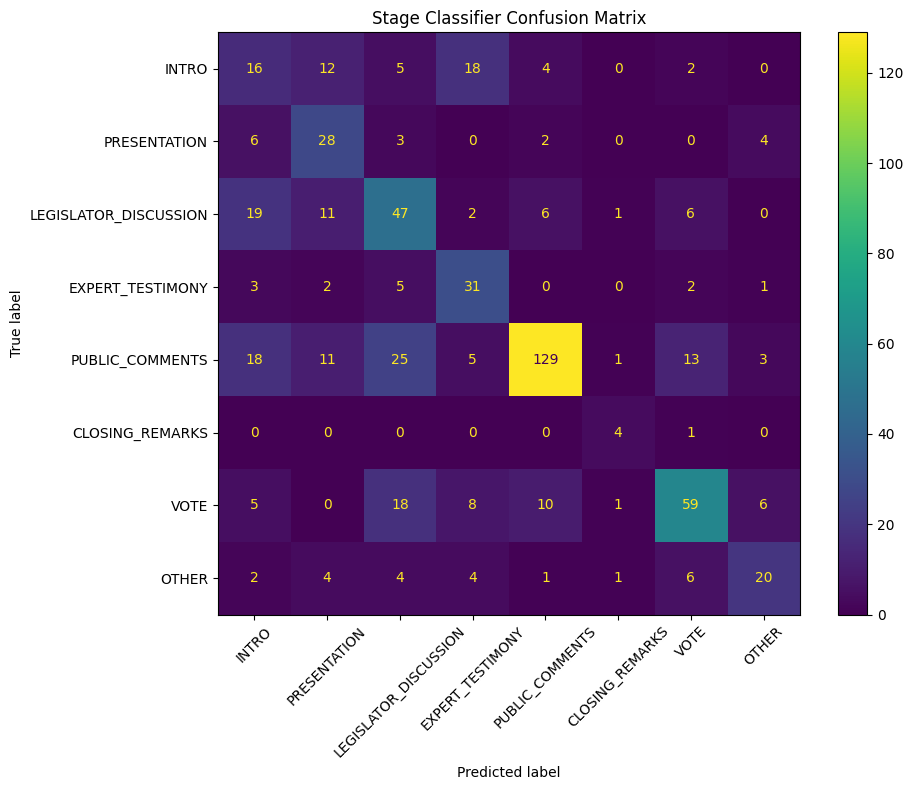

In [15]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

# Filter to only labels present in test set
labels = [label for label in label_order if label in y_test.unique()]

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    labels=labels,
    xticks_rotation=45,
    ax=ax,
)

ax.set_title('Stage Classifier Confusion Matrix')
plt.tight_layout()
plt.show()

In [16]:
# Use the parser's predict_hearing_sections method
labels = parser.predict_hearing_sections(
    hearing=sampled_hearings[0],
    utterances_df=utterances_df,
    smooth=False,
)

print(labels)

['OTHER', 'OTHER', 'OTHER', 'PRESENTATION', 'PRESENTATION', 'PRESENTATION', 'PRESENTATION', 'PUBLIC_COMMENTS', 'PRESENTATION', 'PUBLIC_COMMENTS', 'VOTE', 'PUBLIC_COMMENTS', 'PRESENTATION', 'PUBLIC_COMMENTS', 'VOTE', 'PUBLIC_COMMENTS', 'VOTE', 'PUBLIC_COMMENTS', 'VOTE', 'PUBLIC_COMMENTS', 'VOTE', 'VOTE', 'VOTE', 'OTHER', 'LEGISLATOR_DISCUSSION', 'OTHER', 'OTHER', 'LEGISLATOR_DISCUSSION', 'LEGISLATOR_DISCUSSION', 'VOTE', 'LEGISLATOR_DISCUSSION', 'VOTE', 'CLOSING_REMARKS', 'VOTE', 'CLOSING_REMARKS', 'LEGISLATOR_DISCUSSION', 'VOTE', 'VOTE', 'VOTE', 'VOTE', 'CLOSING_REMARKS', 'VOTE']


In [17]:
special_hearing = None
for h in sampled_hearings:
  if h.bid == 'CA_201720180AB2721':
    special_hearing = h
    break

Note: special case of Chairman presenting to someone else: Bill ID CA_201720180SB1293

Special kind of bill discussion: CA_201720180AB1708
Case where you have to use handoff cue: CA_201720180AB2721
CA_201720180SCR159

In [18]:
def pprint_hearing_labels(hearing, parser, utterances_df, labeled_utterances_df):
  """Print formatted transcript with predicted section labels.
  
  Args:
      hearing: The hearing to print
      parser: HearingParser instance with trained model
      utterances_df: DataFrame with utterance features
      labeled_utterances_df: DataFrame with ground truth labels
  """
  pred_labels = parser.predict_hearing_sections(
    hearing=hearing,
    utterances_df=utterances_df,
    smooth=False,
  )
  
  # Filter labeled_utterances_df for this specific hearing
  hearing_labels = labeled_utterances_df[
    (labeled_utterances_df['bid'] == hearing.bid) & 
    (labeled_utterances_df['hid'] == hearing.hid)
  ].sort_values('uid')
  
  true_labels = hearing_labels['section'].values

  print()
  print(f"State:\t\t{hearing.state}")
  print(f"Committee:\t{hearing.cname}")
  print(f"Bill:\t\t{hearing.bid}")
  print(f"Date:\t\t{hearing.hearing_date.strftime('%Y-%m-%d')}")
  print()
  print("Transcript:")
  for i, contribution in enumerate(hearing.utterances):
    speaker = hearing.speakers[contribution.pid]
    print(f'Predicted label:\t[{pred_labels[i] if i < len(pred_labels) else "UNKNOWN"}]')
    print(f'True label:\t\t[{true_labels[i] if i < len(true_labels) else "UNKNOWN"}]')
    first_name = speaker.first_name or "UNKNOWN"
    last_name = speaker.last_name or "UNKNOWN"
    role = "UNKNOWN"
    if speaker.speaker_position:
      role = speaker.speaker_position.name
    name = f"{first_name} {last_name} [{role}]:"
    print(f"{name:<20}")
    print(f"\t{contribution.text}")
    print()
  print()

# Sanity Checks

In [19]:
HearingLoader.pprint_hearing(sampled_hearings[0])


State:		CA
Committee:	Senate Standing Committee on Governance and Finance
Bill:		CA_201720180SCA22
Date:		2018-05-09

Transcript:
Mike McGuire:        we're moving to BILL which is a constitutional amendment 22 senator BILL_AUTHOR this is in regards to school districts and parcel taxes we welcome the good senator the chair of education to the ORG the floor is yours sir
Benjamin Allen:      members many of you know that I came to this position having served for two terms on school board in my hometown of GPE and I was elected in 2008 and literally I think that I was on the ballot for the november election and in october the stock market crashed the subprime mortgage hit full disaster mode and basically my entire time on the school board was spent trying to figure out ways to balance the budget keep our financial controls in place while also making sure we did everything we could to preserve and protect the core programs that made such a difference for our community and our schools the 

In [20]:
pprint_hearing_labels(sampled_hearings[1], parser, utterances_df, labeled_utterances_df)


State:		CA
Committee:	Assembly Standing Committee on Education
Bill:		CA_201720180AB2601
Date:		2018-03-21

Transcript:
Predicted label:	[PRESENTATION]
True label:		[PRESENTATION]
Shirley Weber [BILL_AUTHOR]:
	good afternoon mr chair and members i'm here to present to you BILL which extends ORG it's comprehensive sex education and HIV prevention mandates on traditional public schools to charter schools at the time when we presented the first bill in terms of the healthy youth act it was not ever my thought that it would not apply to all schools because sex education; healthy education is something that every child should have to me it's as fundamental as reading and writing and math and the sciences and but others had a tendency to not see it because we didn't call it out even though we said it was for public schools we didn't call it out and so therefore BILL exists today to ensure that GPE charter school students receive comprehensive sexual health education and HIV prevention educa